# ML Final Project — Airline Flight Delay Prediction
**Dataset:** [Airline Delay — Kaggle](https://www.kaggle.com/datasets/sriharshaeedala/airline-delay)  
**Period:** August 2013 – August 2023  
**Goal:** Predict the number of delayed flights (`arr_del15`) per carrier-airport-month combination, and identify the primary causes of delay.

---

## Table of Contents
1. [Setup & Data Loading](#1)
2. [Dataset Overview](#2)
3. [Missing Values & Data Quality](#3)
4. [Univariate Analysis](#4)
5. [Bivariate / Correlation Analysis](#5)
6. [Time-Series Trends](#6)
7. [Carrier Performance](#7)
8. [Airport Analysis](#8)
9. [Delay Cause Breakdown](#9)
10. [Feature Engineering Preview](#10)
11. [Key Findings & Next Steps](#11)

<a id='1'></a>
## 1. Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Plot defaults
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 4)

print('Libraries loaded.')

Libraries loaded.


In [ ]:
from data_loader import load_data

df = load_data()
df.head()

<a id='2'></a>
## 2. Dataset Overview

Each row represents **one carrier at one airport for one year-month**.  
The 21 columns fall into four groups:

| Group | Columns |
|---|---|
| Identifiers | `year`, `month`, `carrier`, `carrier_name`, `airport`, `airport_name` |
| Flight counts | `arr_flights`, `arr_del15`, `arr_cancelled`, `arr_diverted` |
| Delay counts (# flights) | `carrier_ct`, `weather_ct`, `nas_ct`, `security_ct`, `late_aircraft_ct` |
| Delay times (minutes) | `arr_delay`, `carrier_delay`, `weather_delay`, `nas_delay`, `security_delay`, `late_aircraft_delay` |

In [4]:
print('Shape:', df.shape)
print('\nColumn dtypes:')
print(df.dtypes)

Shape: (171666, 21)

Column dtypes:
year                     int64
month                    int64
carrier                    str
carrier_name               str
airport                    str
airport_name               str
arr_flights            float64
arr_del15              float64
carrier_ct             float64
weather_ct             float64
nas_ct                 float64
security_ct            float64
late_aircraft_ct       float64
arr_cancelled          float64
arr_diverted           float64
arr_delay              float64
carrier_delay          float64
weather_delay          float64
nas_delay              float64
security_delay         float64
late_aircraft_delay    float64
dtype: object


In [5]:
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [6]:
df.describe().round(2)

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,171666.00,171666.00,171426.00,171223.00,171426.00,171426.00,171426.00,171426.00,171426.00,171426.00,171426.00,171426.00,171426.00,171426.00,171426.00,171426.00,171426.00
mean,2018.55,6.49,362.53,66.43,20.80,2.25,19.38,0.16,23.77,7.53,0.86,4239.49,1437.19,222.56,920.65,7.38,1651.70
std,2.89,3.44,992.89,179.54,50.32,7.31,61.68,0.72,72.39,43.65,3.77,12618.57,4215.68,821.09,3423.51,41.78,5221.88
min,2013.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2016.00,4.00,50.00,6.00,2.16,0.00,1.00,0.00,1.23,0.00,0.00,335.00,110.00,0.00,34.00,0.00,65.00
50%,2019.00,7.00,100.00,17.00,6.40,0.40,3.91,0.00,5.00,1.00,0.00,1018.00,375.00,18.00,146.00,0.00,320.00
75%,2021.00,9.00,250.00,47.00,17.26,1.86,11.71,0.00,15.26,4.00,1.00,2884.00,1109.00,146.00,477.00,0.00,1070.00
max,2023.00,12.00,21977.00,4176.00,1293.91,266.42,1884.42,58.69,2069.07,4951.00,197.00,438783.00,196944.00,31960.00,112018.00,3760.00,227959.00


In [7]:
print('Years covered:  ', sorted(df['year'].unique()))
print('Months covered: ', sorted(df['month'].unique()))
print('Unique carriers:', df['carrier'].nunique())
print('Unique airports:', df['airport'].nunique())

Years covered:   [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Months covered:  [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Unique carriers: 21
Unique airports: 395


<a id='3'></a>
## 3. Missing Values & Data Quality

                     count   pct
arr_del15              443  0.26
arr_flights            240  0.14
carrier_ct             240  0.14
weather_ct             240  0.14
nas_ct                 240  0.14
security_ct            240  0.14
late_aircraft_ct       240  0.14
arr_cancelled          240  0.14
arr_diverted           240  0.14
arr_delay              240  0.14
carrier_delay          240  0.14
weather_delay          240  0.14
nas_delay              240  0.14
security_delay         240  0.14
late_aircraft_delay    240  0.14


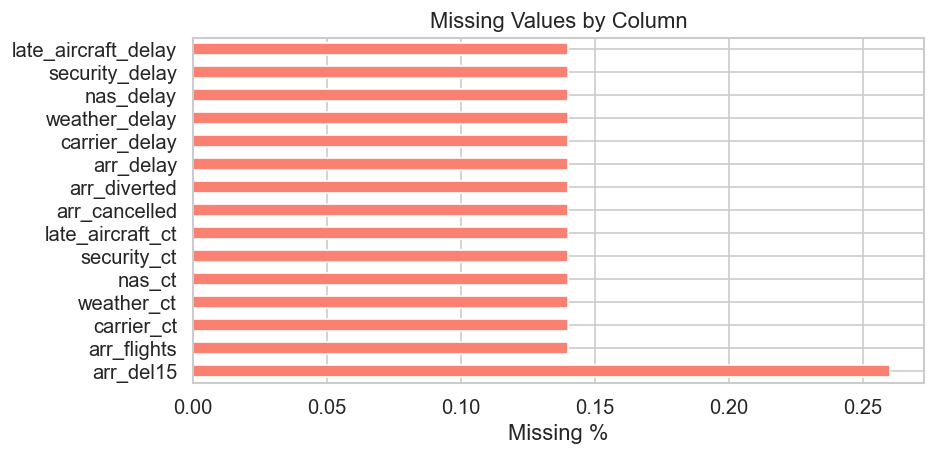

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False)

if missing_df.empty:
    print('No missing values found.')
else:
    print(missing_df)
    fig, ax = plt.subplots(figsize=(8, 4))
    missing_df['pct'].plot(kind='barh', ax=ax, color='salmon')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column')
    plt.tight_layout()
    plt.show()

In [9]:
dup_count = df.duplicated(subset=['year','month','carrier','airport']).sum()
print(f'Duplicate (year, month, carrier, airport) rows: {dup_count}')

Duplicate (year, month, carrier, airport) rows: 0


In [10]:
# Sanity: arr_del15 should never exceed arr_flights
bad_rows = df[df['arr_del15'] > df['arr_flights']]
print(f'Rows where arr_del15 > arr_flights: {len(bad_rows)}')

# Sanity: sum of cause counts should roughly equal arr_del15
cause_ct_cols = ['carrier_ct','weather_ct','nas_ct','security_ct','late_aircraft_ct']
df['ct_sum'] = df[cause_ct_cols].sum(axis=1)
df['ct_diff'] = (df['ct_sum'] - df['arr_del15']).abs()
print(f'Max abs difference (ct_sum vs arr_del15): {df["ct_diff"].max():.2f}')
df.drop(columns=['ct_sum','ct_diff'], inplace=True)

Rows where arr_del15 > arr_flights: 0
Max abs difference (ct_sum vs arr_del15): 1.00


<a id='4'></a>
## 4. Univariate Analysis

We examine the distributions of the key numeric variables.

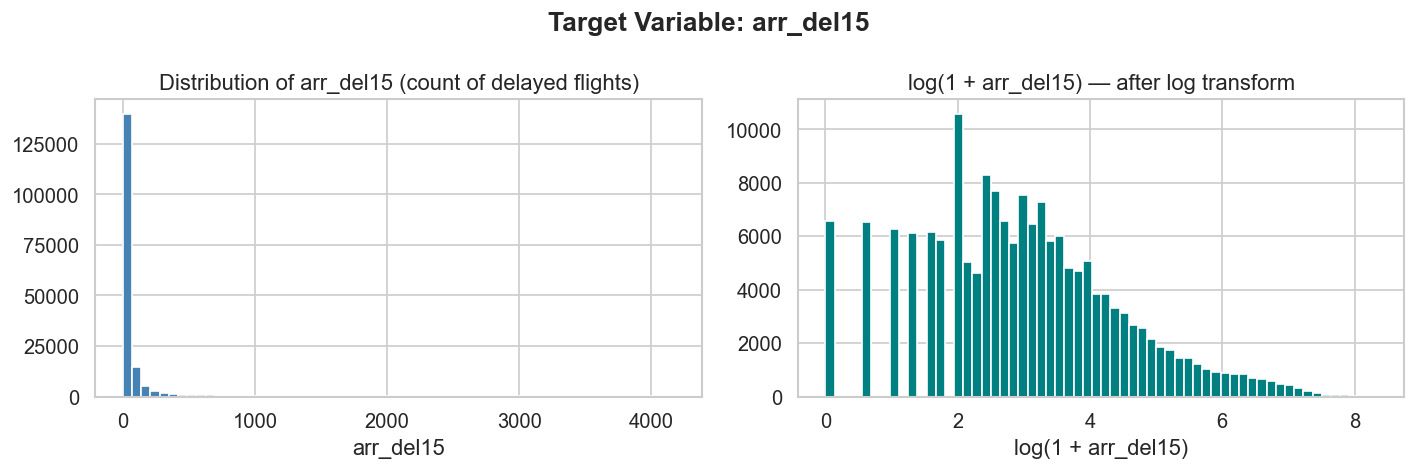

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['arr_del15'].dropna(), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of arr_del15 (count of delayed flights)')
axes[0].set_xlabel('arr_del15')

axes[1].hist(np.log1p(df['arr_del15'].dropna()), bins=60, color='teal', edgecolor='white')
axes[1].set_title('log(1 + arr_del15) — after log transform')
axes[1].set_xlabel('log(1 + arr_del15)')

plt.suptitle('Target Variable: arr_del15', fontweight='bold')
plt.tight_layout()
plt.show()

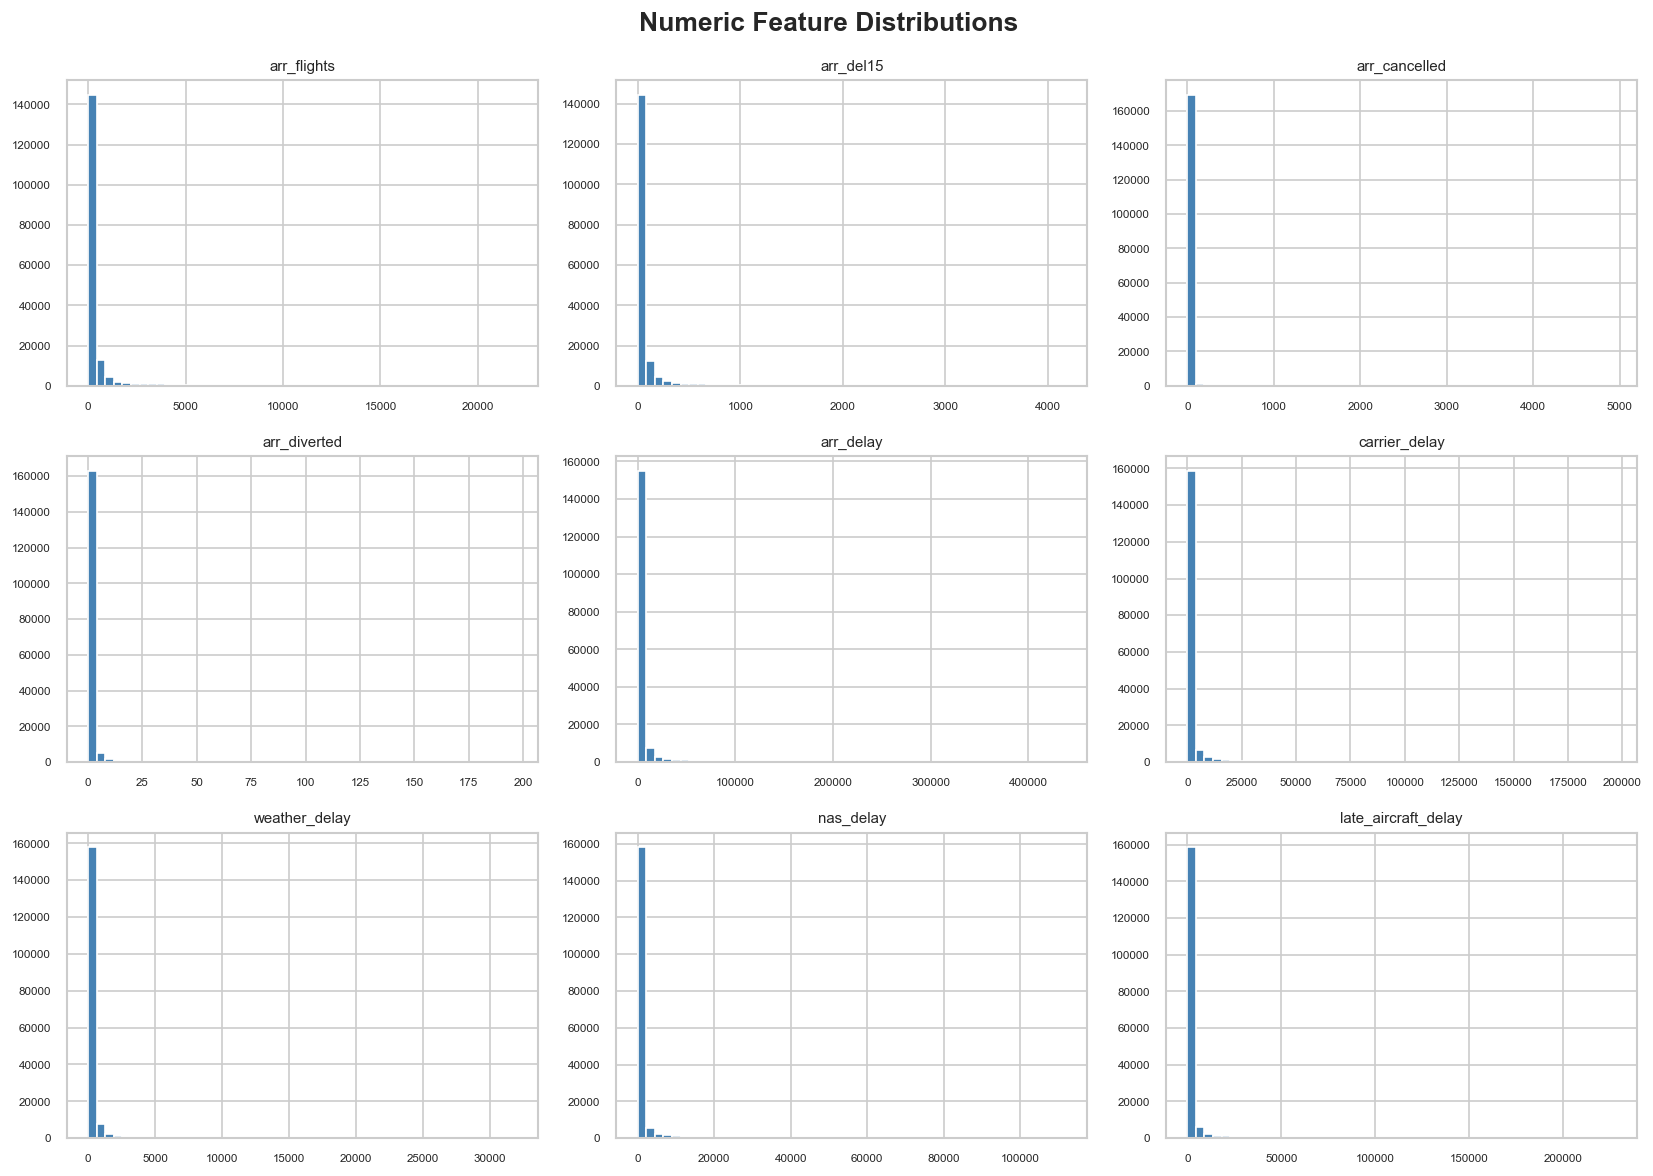

In [12]:
num_cols = ['arr_flights','arr_del15','arr_cancelled','arr_diverted',
            'arr_delay','carrier_delay','weather_delay','nas_delay','late_aircraft_delay']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)

plt.suptitle('Numeric Feature Distributions', fontweight='bold')
plt.tight_layout()
plt.show()

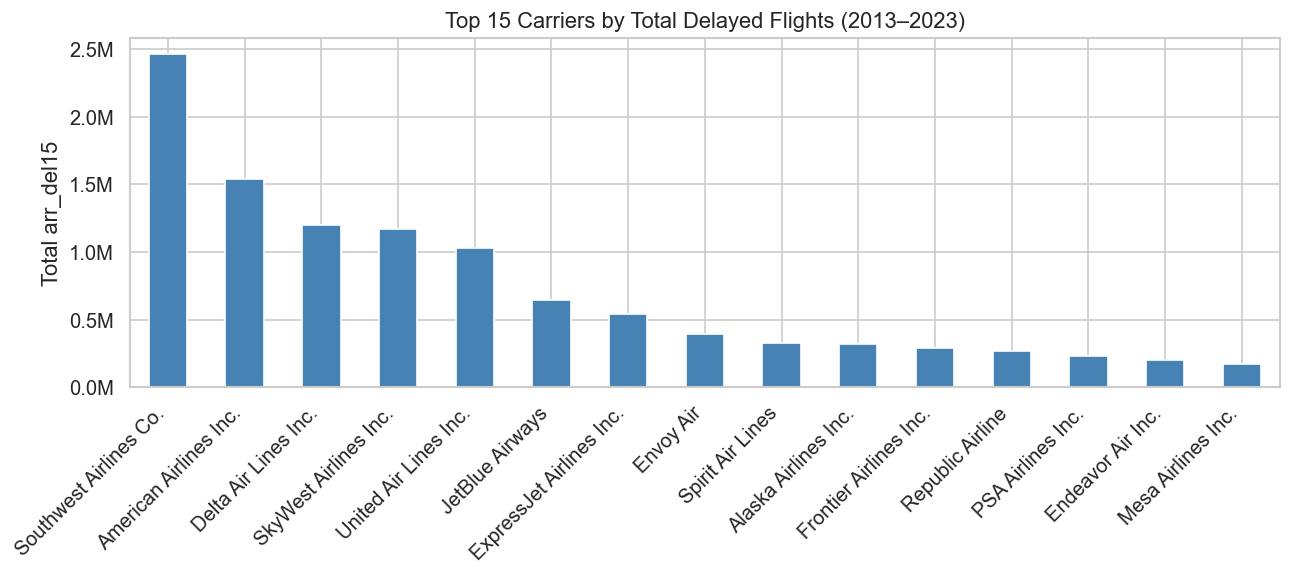

In [13]:
# Top 15 carriers by total delayed flights
top_carriers = (
    df.groupby('carrier_name')['arr_del15']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(11, 5))
top_carriers.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Carriers by Total Delayed Flights (2013–2023)')
ax.set_ylabel('Total arr_del15')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<a id='5'></a>
## 5. Bivariate / Correlation Analysis

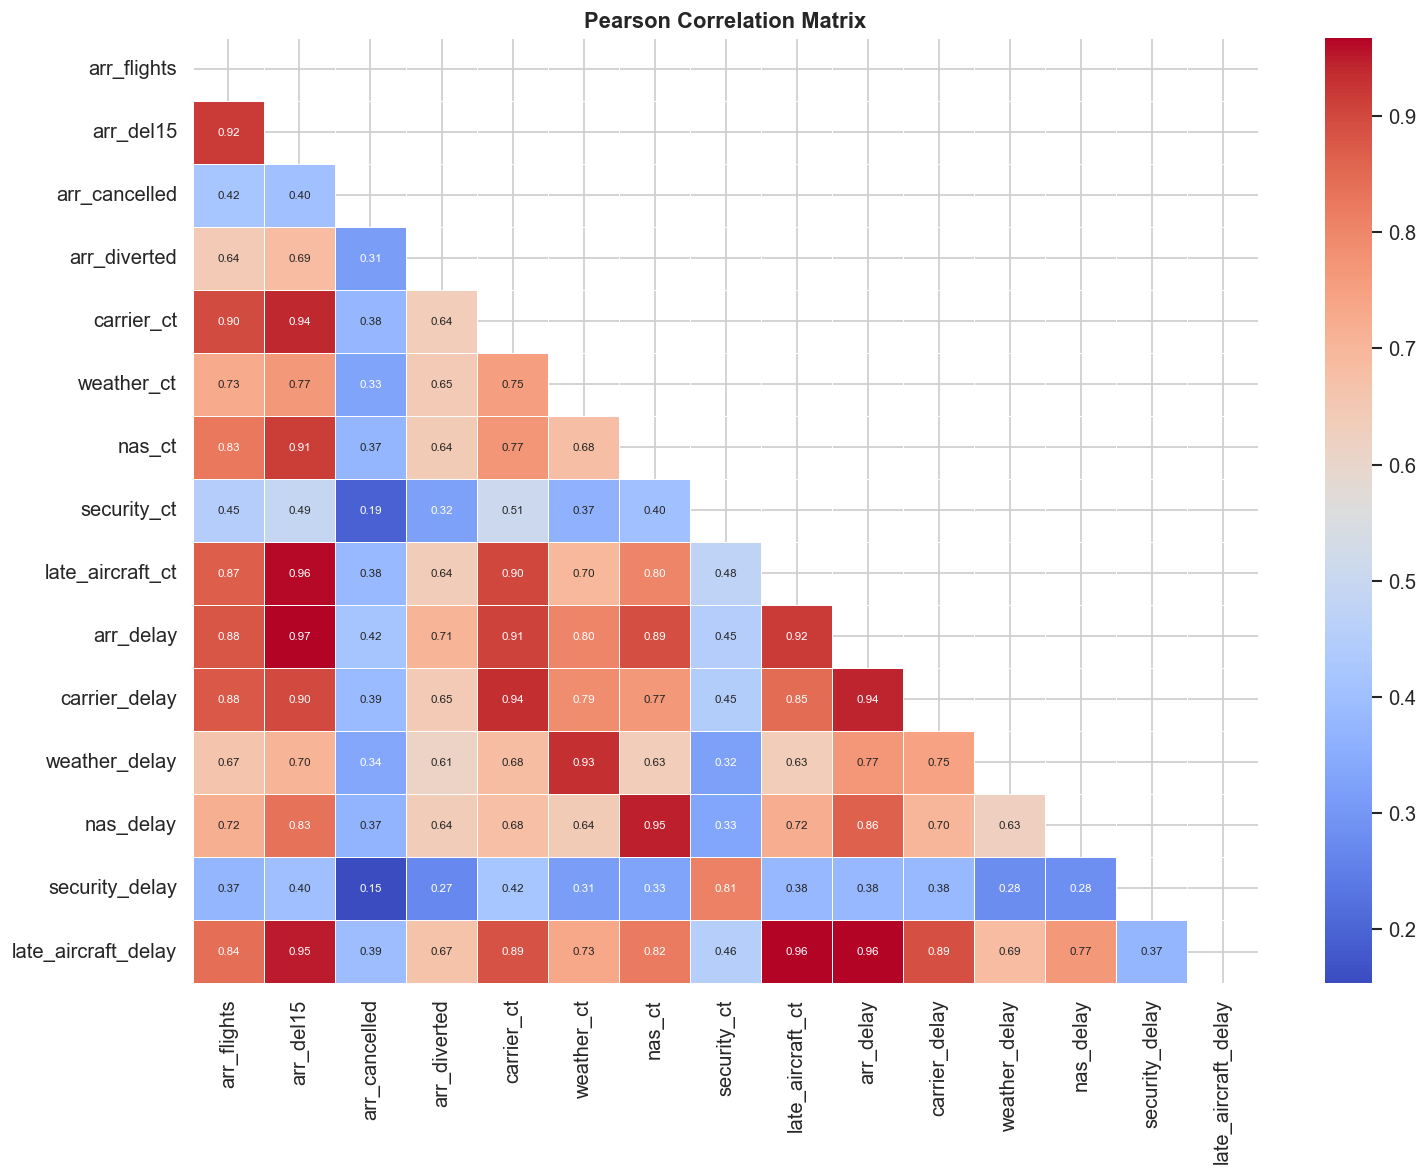

In [14]:
corr_cols = [
    'arr_flights','arr_del15','arr_cancelled','arr_diverted',
    'carrier_ct','weather_ct','nas_ct','security_ct','late_aircraft_ct',
    'arr_delay','carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay'
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_title('Pearson Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

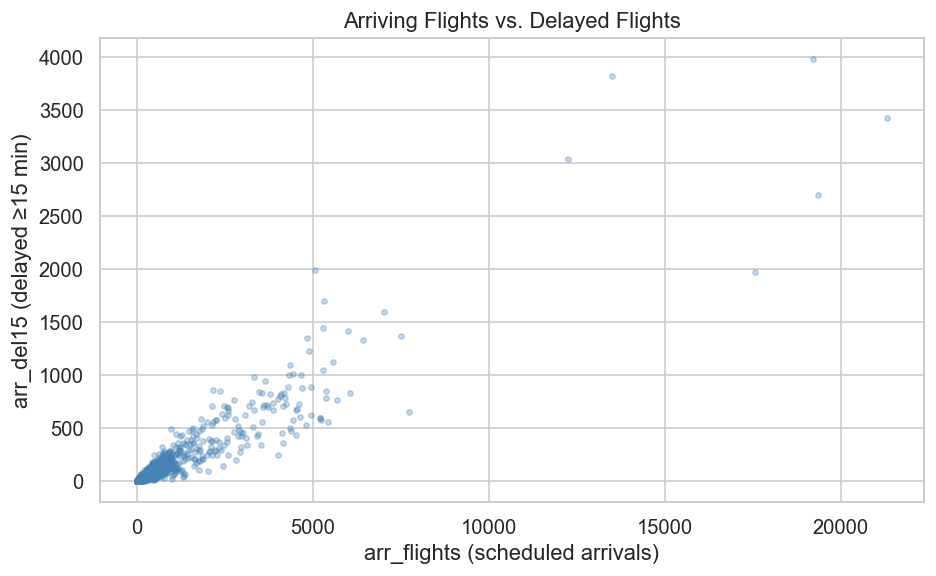

In [15]:
# arr_flights vs arr_del15  — is delay simply a function of volume?
sample = df.dropna(subset=['arr_flights','arr_del15']).sample(min(3000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample['arr_flights'], sample['arr_del15'], alpha=0.3, s=10, color='steelblue')
ax.set_xlabel('arr_flights (scheduled arrivals)')
ax.set_ylabel('arr_del15 (delayed ≥15 min)')
ax.set_title('Arriving Flights vs. Delayed Flights')
plt.tight_layout()
plt.show()

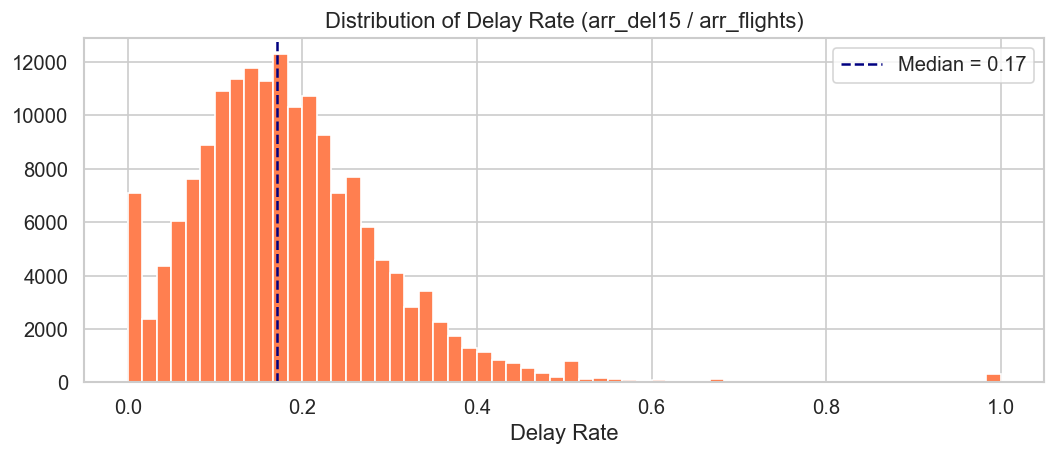

In [16]:
# Derived metric: delay rate (more informative than raw count)
df['delay_rate'] = df['arr_del15'] / df['arr_flights'].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['delay_rate'].dropna(), bins=60, color='coral', edgecolor='white')
ax.set_title('Distribution of Delay Rate (arr_del15 / arr_flights)')
ax.set_xlabel('Delay Rate')
ax.axvline(df['delay_rate'].median(), color='navy', linestyle='--', label=f'Median = {df["delay_rate"].median():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

<a id='6'></a>
## 6. Time-Series Trends

We aggregate nationally by year and by month to spot macro-level trends and seasonality.

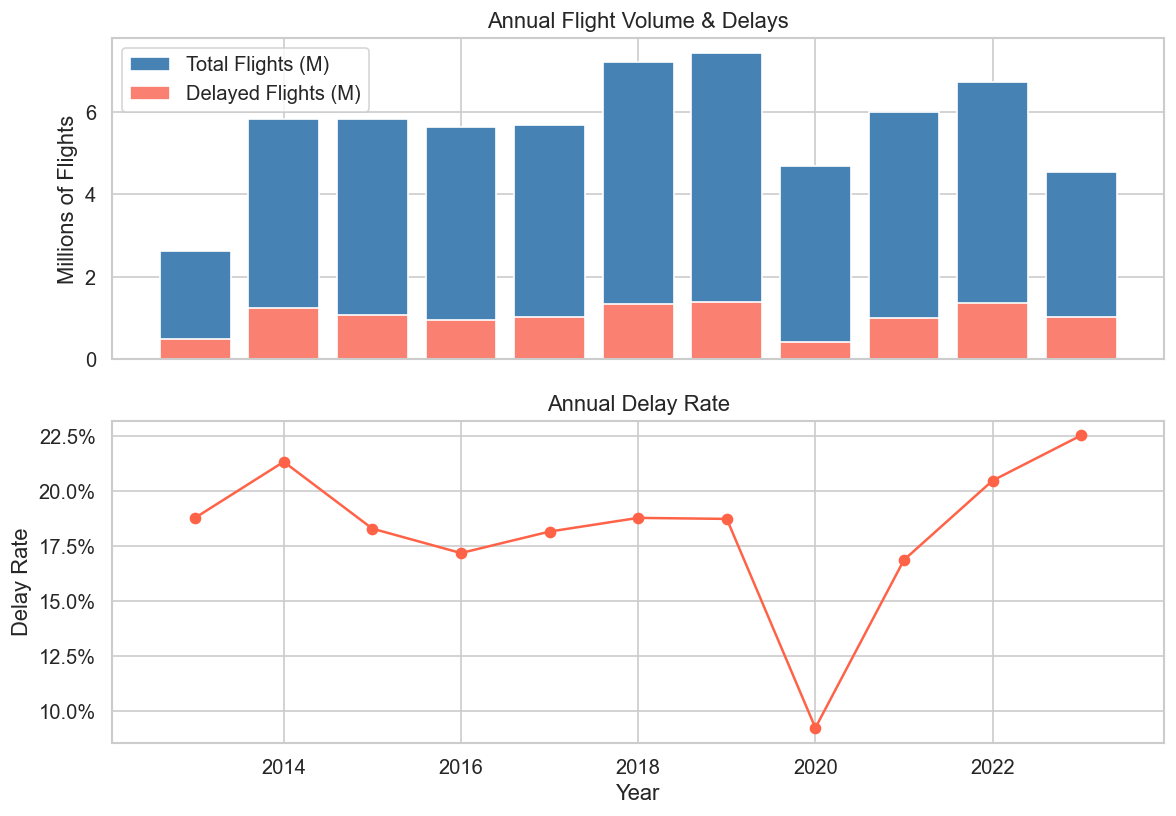

      total_flights  total_delayed  delay_rate
year                                          
2013      2629106.0       493432.0      0.1877
2014      5819811.0      1240528.0      0.2132
2015      5819079.0      1063439.0      0.1828
2016      5617658.0       964239.0      0.1716
2017      5674621.0      1029474.0      0.1814
2018      7206195.0      1352165.0      0.1876
2019      7422037.0      1389253.0      0.1872
2020      4688354.0       431921.0      0.0921
2021      5995397.0      1010332.0      0.1685
2022      6729125.0      1376798.0      0.2046
2023      4545422.0      1023514.0      0.2252


In [17]:
yearly = df.groupby('year').agg(
    total_flights=('arr_flights', 'sum'),
    total_delayed=('arr_del15', 'sum')
).assign(delay_rate=lambda x: x['total_delayed'] / x['total_flights'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.bar(yearly.index, yearly['total_flights'] / 1e6, color='steelblue', label='Total Flights (M)')
ax1.bar(yearly.index, yearly['total_delayed'] / 1e6, color='salmon', label='Delayed Flights (M)')
ax1.set_ylabel('Millions of Flights')
ax1.set_title('Annual Flight Volume & Delays')
ax1.legend()

ax2.plot(yearly.index, yearly['delay_rate'], marker='o', color='tomato')
ax2.set_ylabel('Delay Rate')
ax2.set_xlabel('Year')
ax2.set_title('Annual Delay Rate')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

print(yearly.round(4))

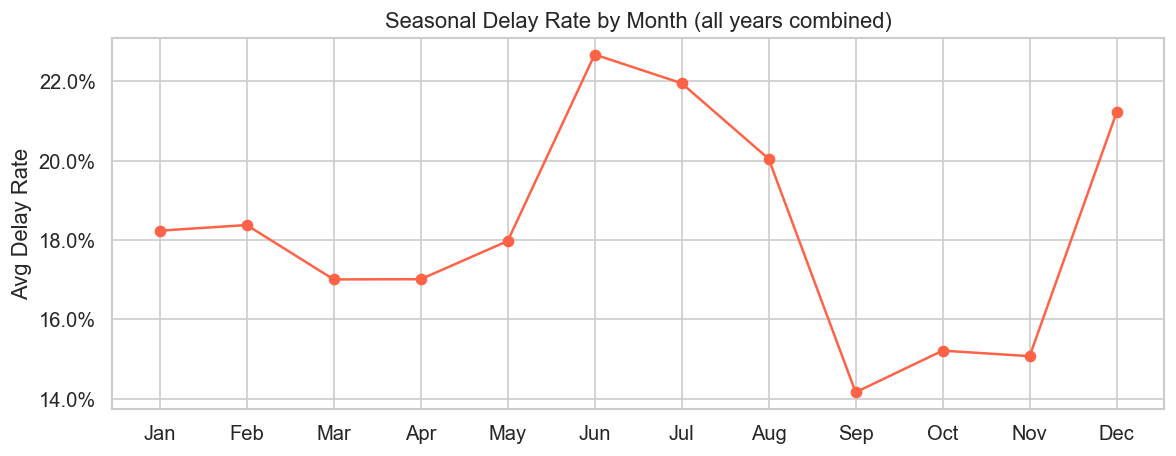

In [18]:
monthly = df.groupby('month').agg(
    total_flights=('arr_flights', 'sum'),
    total_delayed=('arr_del15', 'sum')
).assign(delay_rate=lambda x: x['total_delayed'] / x['total_flights'])

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly['delay_rate'], marker='o', color='tomato')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_ylabel('Avg Delay Rate')
ax.set_title('Seasonal Delay Rate by Month (all years combined)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

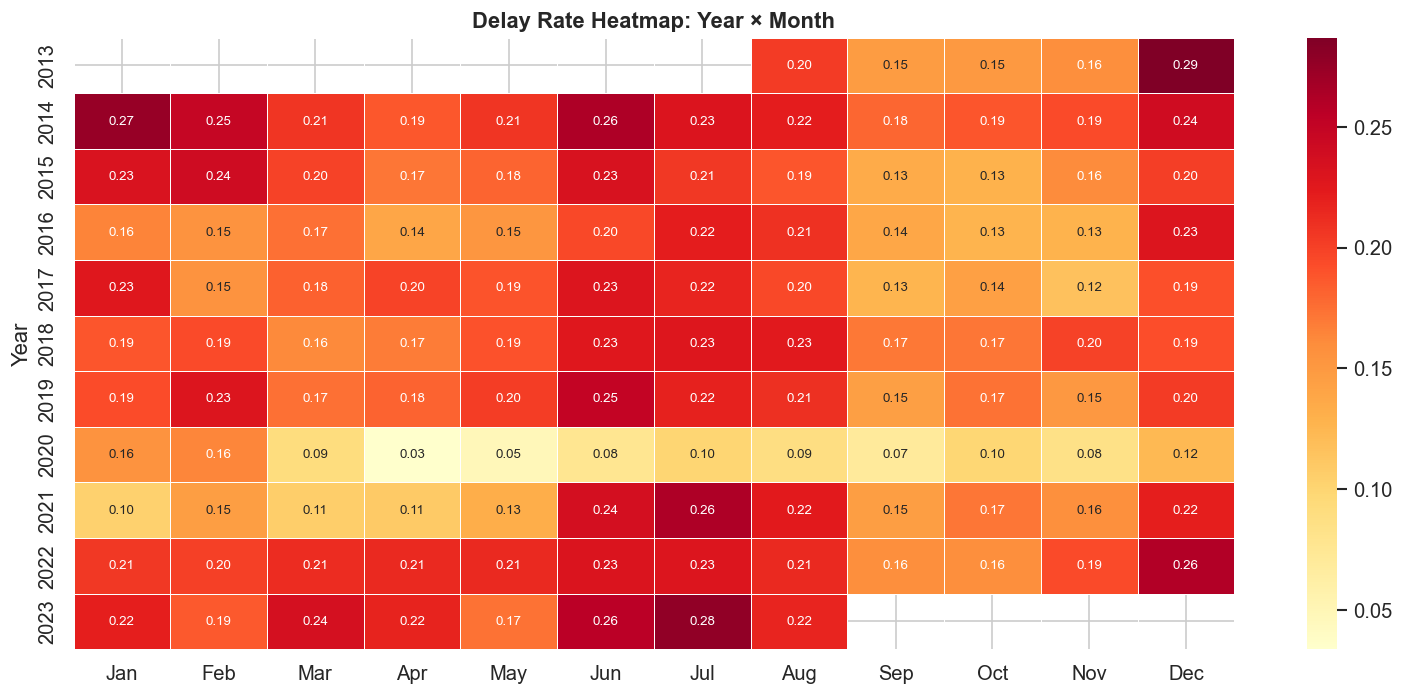

In [19]:
pivot = df.groupby(['year','month'])['delay_rate'].mean().unstack('month')
pivot.columns = month_labels[:len(pivot.columns)]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.3,
            ax=ax, annot_kws={'size': 8})
ax.set_title('Delay Rate Heatmap: Year × Month', fontweight='bold')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

<a id='7'></a>
## 7. Carrier Performance

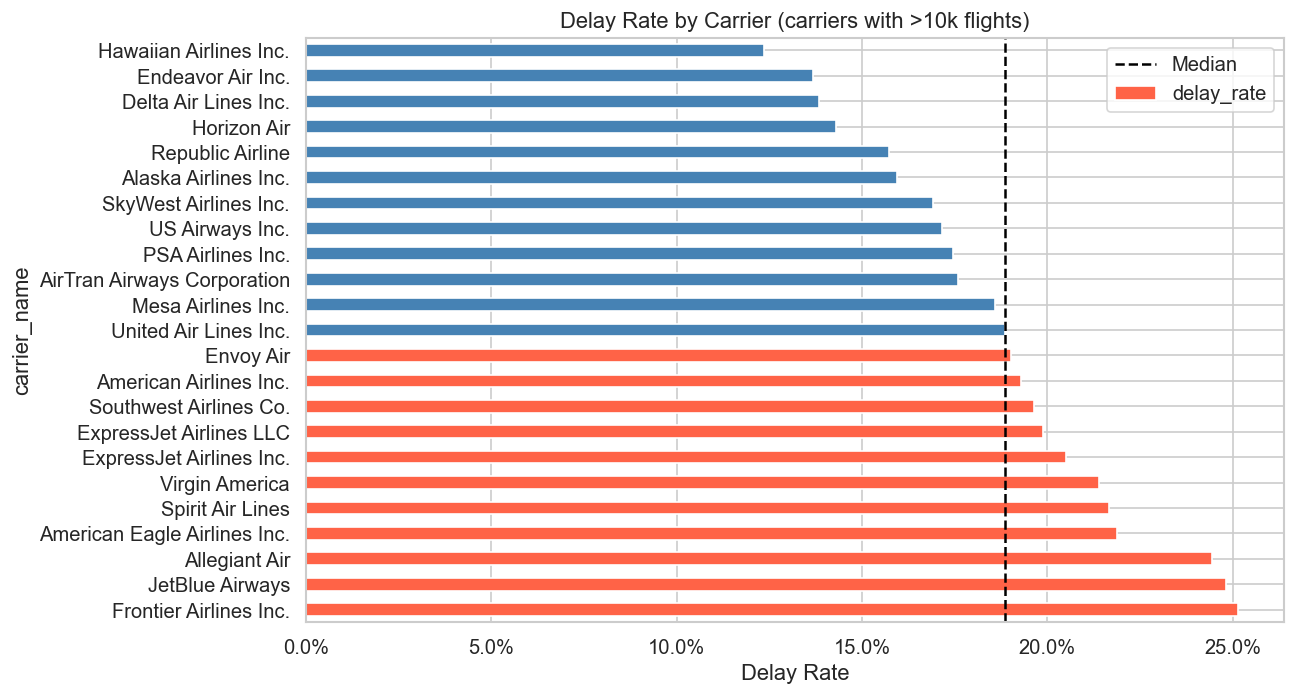

In [20]:
carrier_stats = (
    df.groupby('carrier_name')
    .agg(total_flights=('arr_flights','sum'), total_delayed=('arr_del15','sum'))
    .assign(delay_rate=lambda x: x['total_delayed'] / x['total_flights'])
    .query('total_flights > 10000')   # filter out micro carriers
    .sort_values('delay_rate', ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['tomato' if r > carrier_stats['delay_rate'].median() else 'steelblue'
          for r in carrier_stats['delay_rate']]
carrier_stats['delay_rate'].plot(kind='barh', ax=ax, color=colors)
ax.axvline(carrier_stats['delay_rate'].median(), linestyle='--', color='black', label='Median')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Delay Rate by Carrier (carriers with >10k flights)')
ax.set_xlabel('Delay Rate')
ax.legend()
plt.tight_layout()
plt.show()

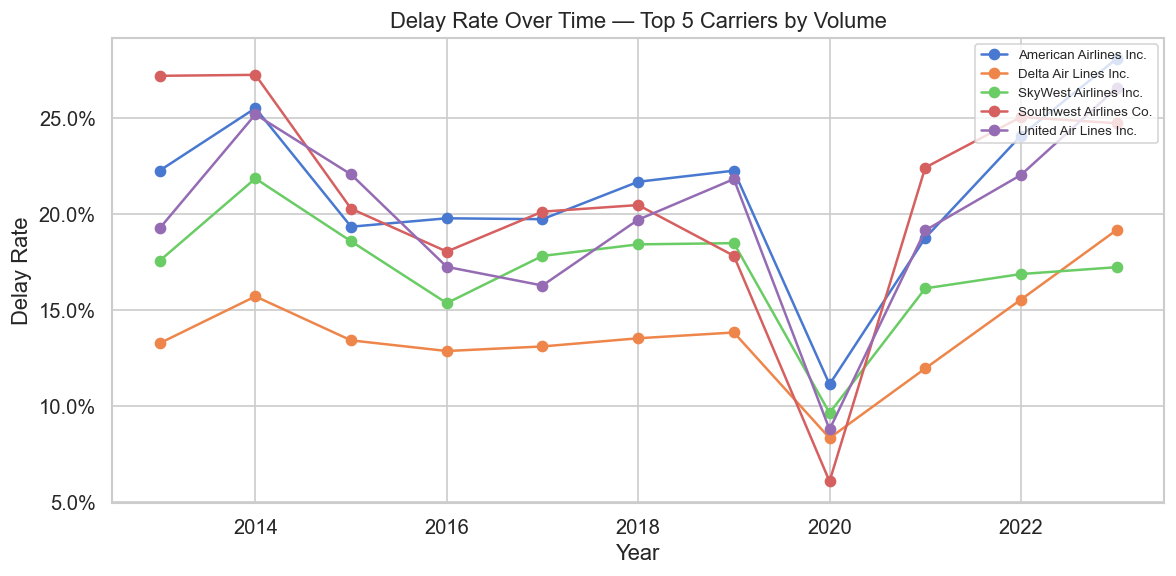

In [21]:
# Trend for the top 5 carriers by total volume
top5 = (
    df.groupby('carrier_name')['arr_flights']
    .sum()
    .nlargest(5)
    .index.tolist()
)

carrier_yr = (
    df[df['carrier_name'].isin(top5)]
    .groupby(['year','carrier_name'])
    .agg(dr=('delay_rate','mean'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
for name, grp in carrier_yr.groupby('carrier_name'):
    ax.plot(grp['year'], grp['dr'], marker='o', label=name)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Delay Rate Over Time — Top 5 Carriers by Volume')
ax.set_xlabel('Year')
ax.set_ylabel('Delay Rate')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

<a id='8'></a>
## 8. Airport Analysis

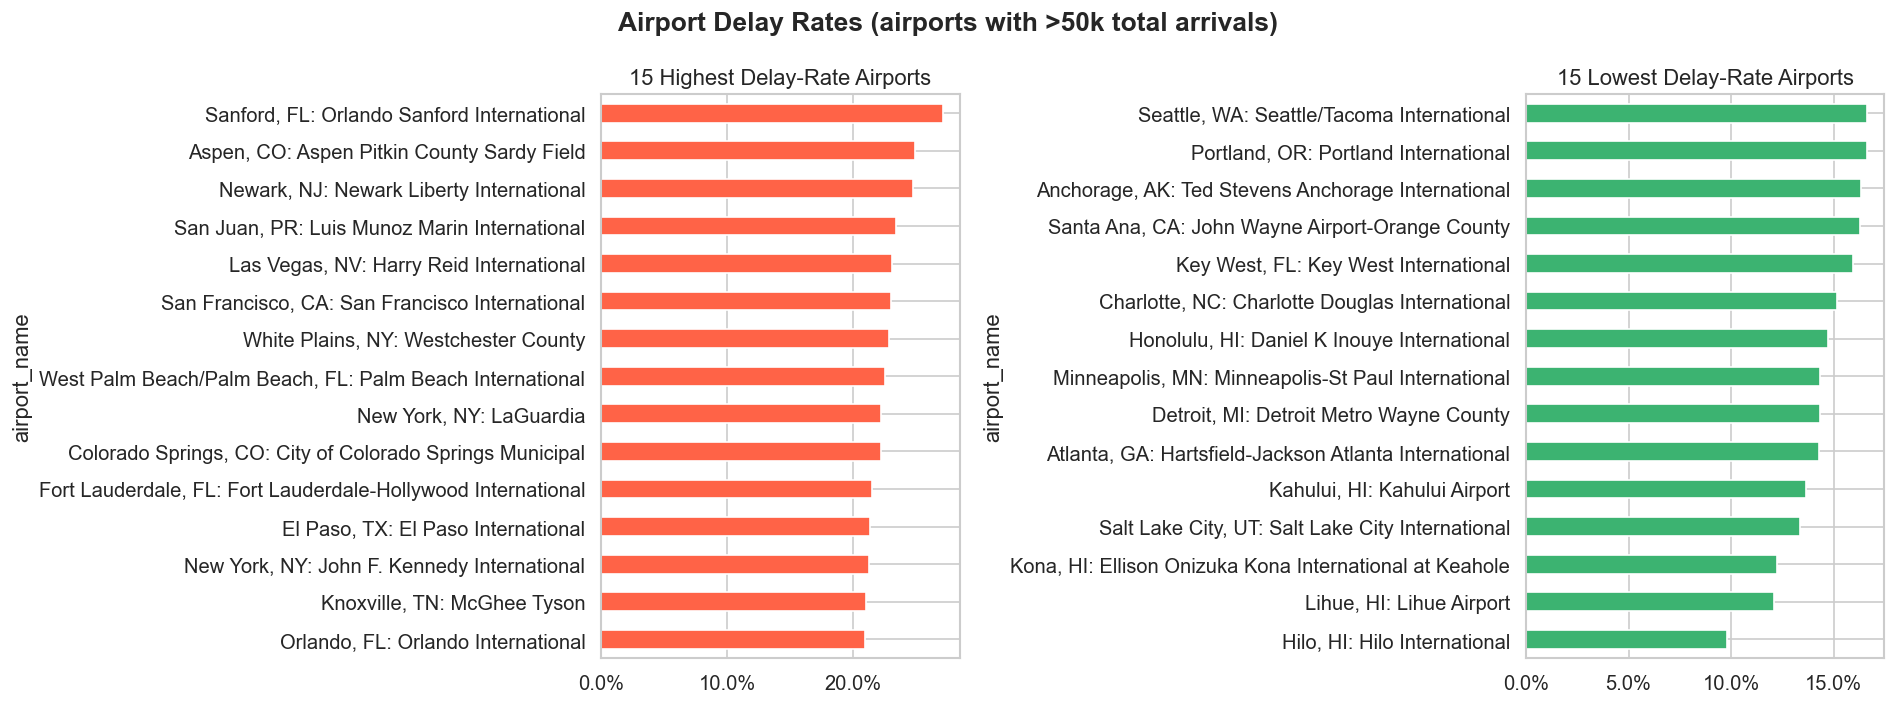

In [22]:
airport_stats = (
    df.groupby('airport_name')
    .agg(total_flights=('arr_flights','sum'), total_delayed=('arr_del15','sum'))
    .assign(delay_rate=lambda x: x['total_delayed'] / x['total_flights'])
    .query('total_flights > 50000')
    .sort_values('delay_rate', ascending=False)
)

# Top 15 worst and best airports
worst15 = airport_stats.head(15)
best15  = airport_stats.tail(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

worst15['delay_rate'].plot(kind='barh', ax=ax1, color='tomato')
ax1.set_title('15 Highest Delay-Rate Airports')
ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.invert_yaxis()

best15['delay_rate'].plot(kind='barh', ax=ax2, color='mediumseagreen')
ax2.set_title('15 Lowest Delay-Rate Airports')
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.invert_yaxis()

plt.suptitle('Airport Delay Rates (airports with >50k total arrivals)', fontweight='bold')
plt.tight_layout()
plt.show()

<a id='9'></a>
## 9. Delay Cause Breakdown

The dataset tracks five delay causes. Understanding their relative contribution informs feature selection.

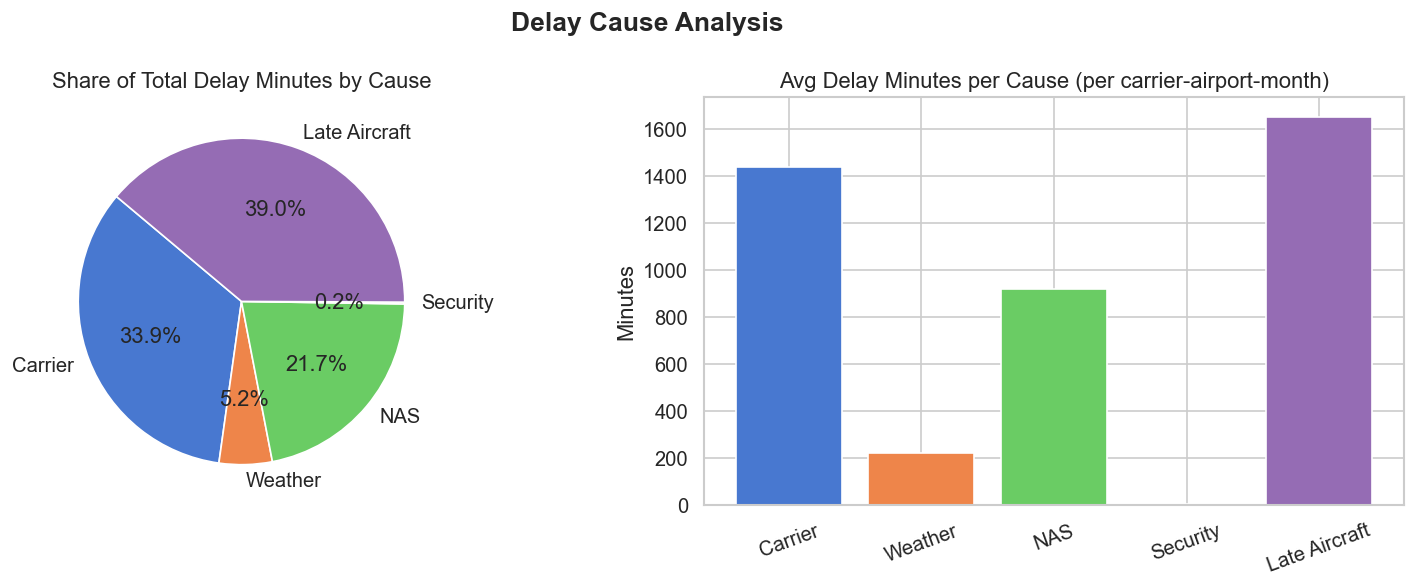

In [23]:
cause_delay_cols = {
    'Carrier':       'carrier_delay',
    'Weather':       'weather_delay',
    'NAS':           'nas_delay',
    'Security':      'security_delay',
    'Late Aircraft': 'late_aircraft_delay'
}

cause_totals = {label: df[col].sum() for label, col in cause_delay_cols.items()}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
ax1.pie(cause_totals.values(), labels=cause_totals.keys(),
        autopct='%1.1f%%', startangle=140,
        colors=sns.color_palette('muted', len(cause_totals)))
ax1.set_title('Share of Total Delay Minutes by Cause')

# Bar chart — average delay minutes per cause per row
cause_means = {label: df[col].mean() for label, col in cause_delay_cols.items()}
ax2.bar(cause_means.keys(), cause_means.values(),
        color=sns.color_palette('muted', len(cause_means)), edgecolor='white')
ax2.set_title('Avg Delay Minutes per Cause (per carrier-airport-month)')
ax2.set_ylabel('Minutes')
plt.xticks(rotation=20)

plt.suptitle('Delay Cause Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

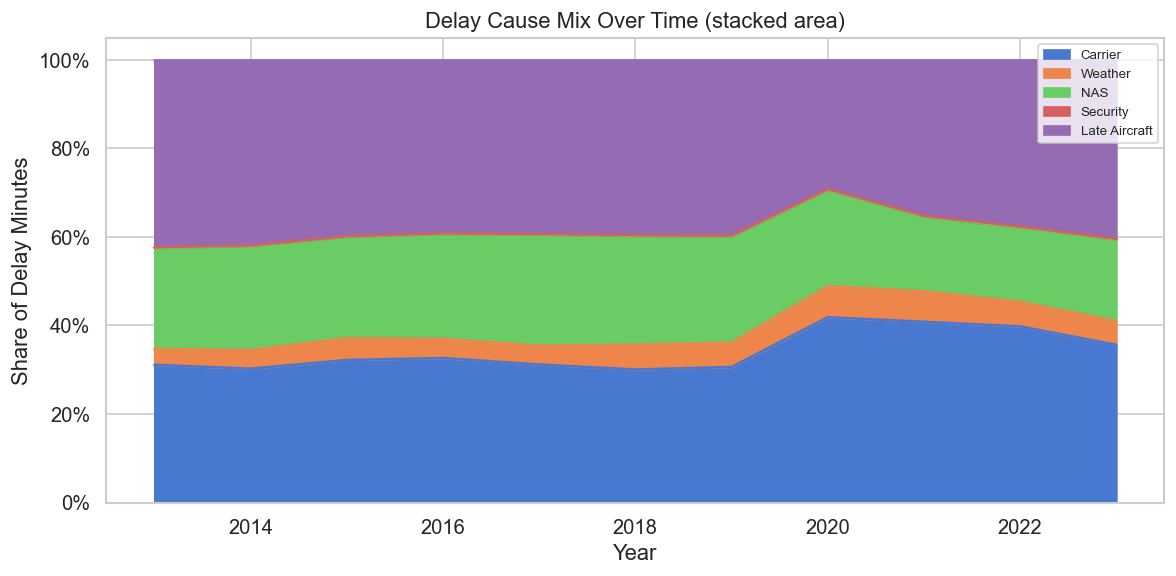

In [24]:
cause_yr = df.groupby('year')[
    list(cause_delay_cols.values())
].sum().rename(columns={v: k for k, v in cause_delay_cols.items()})

cause_yr_pct = cause_yr.div(cause_yr.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
cause_yr_pct.plot(kind='area', stacked=True, ax=ax,
                  color=sns.color_palette('muted', 5))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Delay Cause Mix Over Time (stacked area)')
ax.set_xlabel('Year')
ax.set_ylabel('Share of Delay Minutes')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

<a id='10'></a>
## 10. Feature Engineering Preview

These derived features will be passed to the ML models in `main.py`.

In [ ]:
from data_loader import build_features

df_feat = build_features(df)
print('Feature-engineered dataframe shape:', df_feat.shape)
df_feat[['delay_rate','cancel_rate','carrier_share','weather_share',
          'month_sin','month_cos','is_peak_season']].describe().round(3)

<a id='11'></a>
## 11. Key Findings & Next Steps

### Key Findings from EDA
| Finding | Detail |
|---|---|
| Right-skewed target | `arr_del15` is heavily right-skewed; log transform recommended |
| Strong volume effect | `arr_del15` correlates strongly with `arr_flights` → use `delay_rate` as target |
| Seasonality | Delays peak in **June–August** (summer) and **December** (holidays) |
| COVID dip | 2020 shows a dramatic volume drop with unusual delay patterns |
| Top delay causes | **Late aircraft** and **carrier** causes dominate; security is negligible |
| Carrier spread | Delay rates vary substantially across carriers even controlling for volume |

### ML Plan (implemented in `main.py`)
| Step | Details |
|---|---|
| **Target** | `delay_rate = arr_del15 / arr_flights` (regression) |
| **Train/test split** | Time-based: train on 2013–2020, test on 2021–2023 |
| **Baseline** | `DummyRegressor(strategy='mean')` |
| **Models** | Linear Regression, Random Forest, Gradient Boosting |
| **Evaluation** | MAE, RMSE, R² on hold-out test set |
| **Feature importance** | SHAP values / built-in importances for interpretability |

### Open Questions
- Should 2020 (COVID) be excluded from training or flagged as a special feature?
- Should we encode `carrier` and `airport` as target-encoded vs. one-hot?
- Is there a worthwhile classification formulation (high-delay airport-month)?